# Chi-Square Test — Practical Notebook

This notebook accompanies the textbook-style README. It focuses only on categorical-data chi-square methods: goodness-of-fit, independence, homogeneity, expected frequencies, residuals, effect size, and practical interpretation.

## Learning Objectives

- calculate expected frequencies;
- calculate chi-square statistics manually;
- perform goodness-of-fit tests;
- perform independence tests;
- understand homogeneity tests;
- check expected-frequency conditions;
- calculate Cramer's V;
- inspect cell contributions and residuals;
- use Python for practical chi-square analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

## 1. Goodness-of-Fit Example

Observed product choices are 90, 70, and 40. The expected proportions are 0.50, 0.30, and 0.20.

In [2]:
observed = np.array([90, 70, 40])
expected_proportions = np.array([0.50, 0.30, 0.20])
expected = observed.sum() * expected_proportions

print('Observed:', observed)
print('Expected:', expected)

Observed: [90 70 40]
Expected: [100.  60.  40.]


## 2. Manual Chi-Square Calculation

In [3]:
contributions = (observed - expected)**2 / expected
chi_square = contributions.sum()
df = len(observed) - 1
p_value = stats.chi2.sf(chi_square, df)

print('Cell contributions:', contributions)
print('Chi-square:', chi_square)
print('Degrees of freedom:', df)
print('p-value:', p_value)

Cell contributions: [1.         1.66666667 0.        ]
Chi-square: 2.666666666666667
Degrees of freedom: 2
p-value: 0.2635971381157267


## 3. Goodness-of-Fit with SciPy

In [4]:
result = stats.chisquare(f_obs=observed, f_exp=expected)
print('Chi-square:', result.statistic)
print('p-value:', result.pvalue)

Chi-square: 2.666666666666667
p-value: 0.2635971381157267


## 4. Independence Example

Create a contingency table for customer type and payment method.

In [5]:
observed_table = np.array([
    [20, 30, 50],
    [30, 40, 30]
])

chi2, p, dof, expected = stats.chi2_contingency(observed_table, correction=False)

print('Chi-square:', chi2)
print('p-value:', p)
print('Degrees of freedom:', dof)
print('Expected frequencies:\n', expected)

Chi-square: 8.428571428571429
p-value: 0.01478287719483942
Degrees of freedom: 2
Expected frequencies:
 [[25. 35. 40.]
 [25. 35. 40.]]


## 5. Expected Frequencies Manually

For each cell, use $E_{ij}=(R_iC_j)/N$.

In [6]:
row_totals = observed_table.sum(axis=1, keepdims=True)
col_totals = observed_table.sum(axis=0, keepdims=True)
grand_total = observed_table.sum()
expected_manual = row_totals @ col_totals / grand_total
print(expected_manual)

[[25. 35. 40.]
 [25. 35. 40.]]


## 6. Cell Contributions

In [7]:
cell_contributions = (observed_table - expected_manual)**2 / expected_manual
print(cell_contributions)
print('Sum:', cell_contributions.sum())

[[1.         0.71428571 2.5       ]
 [1.         0.71428571 2.5       ]]
Sum: 8.428571428571429


## 7. Pearson Residuals

In [8]:
pearson_residuals = (observed_table - expected_manual) / np.sqrt(expected_manual)
print(pearson_residuals)

[[-1.         -0.84515425  1.58113883]
 [ 1.          0.84515425 -1.58113883]]


## 8. Cramer's V

In [9]:
r, c = observed_table.shape
cramers_v = np.sqrt(chi2 / (observed_table.sum() * min(r-1, c-1)))
print('Cramer\'s V:', cramers_v)

Cramer's V: 0.2052872551885702


## 9. Visualise Observed Frequencies

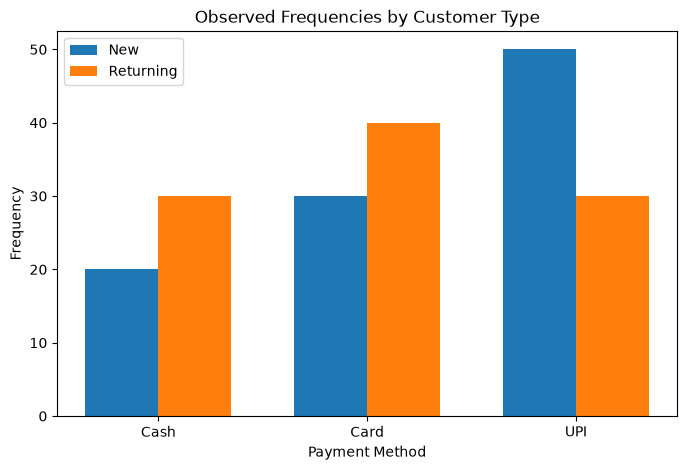

In [10]:
labels = ['Cash', 'Card', 'UPI']
new = observed_table[0]
returning = observed_table[1]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, new, width, label='New')
plt.bar(x + width/2, returning, width, label='Returning')
plt.xticks(x, labels)
plt.xlabel('Payment Method')
plt.ylabel('Frequency')
plt.title('Observed Frequencies by Customer Type')
plt.legend()
plt.show()

## 10. Fair Die Goodness-of-Fit

Six equally likely outcomes have expected probability $1/6$. Use the observed counts from the README.

In [11]:
die_observed = np.array([90, 110, 95, 105, 120, 80])
die_expected = np.repeat(die_observed.sum()/6, 6)
result = stats.chisquare(die_observed, die_expected)
print('Expected:', die_expected)
print('Chi-square:', result.statistic)
print('p-value:', result.pvalue)

Expected: [100. 100. 100. 100. 100. 100.]
Chi-square: 10.5
p-value: 0.06224592809090594


## 11. Fisher's Exact Test for a Small 2 × 2 Table

In [12]:
small_table = np.array([[8, 2], [1, 9]])
result = stats.fisher_exact(small_table)
print('Odds ratio:', result.statistic)
print('p-value:', result.pvalue)

Odds ratio: 36.0
p-value: 0.005477494641581329


## 12. Leverage the Correct Test

Use goodness-of-fit when comparing one categorical distribution with specified proportions. Use independence when examining association between two categorical variables. Use homogeneity when comparing categorical distributions across groups.

## 13. Practice Questions

1. Explain the difference between observed and expected frequency.
2. Calculate the expected frequencies for 100 observations with expected proportions 0.5, 0.3, and 0.2.
3. State the hypotheses for a goodness-of-fit test.
4. State the hypotheses for an independence test.
5. Calculate the degrees of freedom for a 4 × 3 contingency table.
6. Why can very small expected frequencies be problematic?
7. Explain the difference between independence and homogeneity.
8. What does Cramer's V measure?
9. Why does a significant chi-square test not prove causation?
10. Explain the relationship $\chi^2=z^2$ in the equivalent 2 × 2 large-sample setting.

## 14. Final Checklist

Before reporting a chi-square analysis, verify the categorical structure, observed counts, null model, expected frequencies, expected-count conditions, degrees of freedom, chi-square statistic, p-value, effect size where appropriate, and contextual interpretation.